In [ ]:
import os
import pandas as pd
import zipfile
from google.colab import userdata

!pip install kaggle imblearn -q

In [ ]:
# Setup Kaggle credentials
!mkdir -p ~/.kaggle
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{userdata.get("KAGGLE_USERNAME")}","key":"{userdata.get("KAGGLE_KEY")}"}}')
!chmod 600 ~/.kaggle/kaggle.json

SecretNotFoundError: Secret KAGGLE_USERNAME does not exist.

In [ ]:
# Download and unzip dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud -p /content/

zip_file_path = '/content/creditcardfraud.zip'
extracted_dir = '/content/'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_dir)
    print("Dataset downloaded and unzipped.")
else:
    print(f"Error: Zip file not found at {zip_file_path}.")

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.13/dist-packages/kaggle/__init__.py", line 10, in <module>
    api.authenticate()
    ~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/kaggle/api/kaggle_api_extended.py", line 763, in authenticate
    if self._authenticate_with_legacy_apikey():
       ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/kaggle/api/kaggle_api_extended.py", line 808, in _authenticate_with_legacy_apikey
    raise ValueError("Error: Missing %s in configuration." % item)
ValueError: Error: Missing username in configuration.
Dataset downloaded and unzipped.


In [ ]:
# Load dataset
csv_file_path = '/content/creditcard.csv'
df = pd.read_csv(csv_file_path)
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Initial data inspection
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

In [ ]:
# Check for missing values
display(df.isnull().sum())

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Class
0    284315
1       492
Name: count, dtype: int64


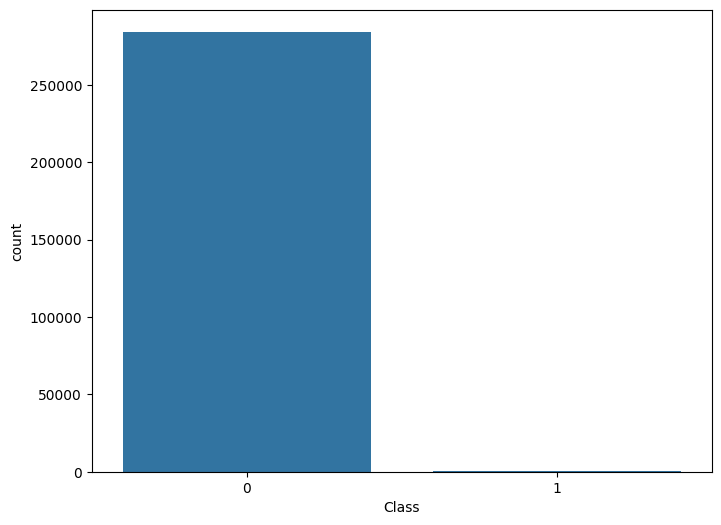

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Class distribution
class_distribution = df['Class'].value_counts()
print(class_distribution)

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.show()

In [ ]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(X.shape, y.shape)

(284807, 30) (284807,)


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Resample the dataset
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print(Counter(y_resampled))
print(X_resampled.shape, y_resampled.shape)

Counter({0: 492, 1: 492})
(984, 30) (984,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(688, 30) (688,)
(296, 30) (296,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)
log_reg_model.fit(X_train, y_train)

# Predictions
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluation
print("Logistic Regression Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))

Logistic Regression Model Evaluation:
Accuracy: 0.9425675675675675
Confusion Matrix:
 [[145   3]
 [ 14 134]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       148
           1       0.98      0.91      0.94       148

    accuracy                           0.94       296
   macro avg       0.95      0.94      0.94       296
weighted avg       0.95      0.94      0.94       296



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Predictions
y_pred_dec_tree = dec_tree_model.predict(X_test)

# Evaluation
print("Decision Tree Classifier Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dec_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dec_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_dec_tree))

Decision Tree Classifier Model Evaluation:
Accuracy: 0.9087837837837838
Confusion Matrix:
 [[135  13]
 [ 14 134]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       148
           1       0.91      0.91      0.91       148

    accuracy                           0.91       296
   macro avg       0.91      0.91      0.91       296
weighted avg       0.91      0.91      0.91       296



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
rand_forest_model = RandomForestClassifier(random_state=42)
rand_forest_model.fit(X_train, y_train)

# Predictions
y_pred_rand_forest = rand_forest_model.predict(X_test)

# Evaluation
print("Random Forest Classifier Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rand_forest))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rand_forest))
print("Classification Report:\n", classification_report(y_test, y_pred_rand_forest))

Random Forest Classifier Model Evaluation:
Accuracy: 0.9391891891891891
Confusion Matrix:
 [[143   5]
 [ 13 135]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       148
           1       0.96      0.91      0.94       148

    accuracy                           0.94       296
   macro avg       0.94      0.94      0.94       296
weighted avg       0.94      0.94      0.94       296



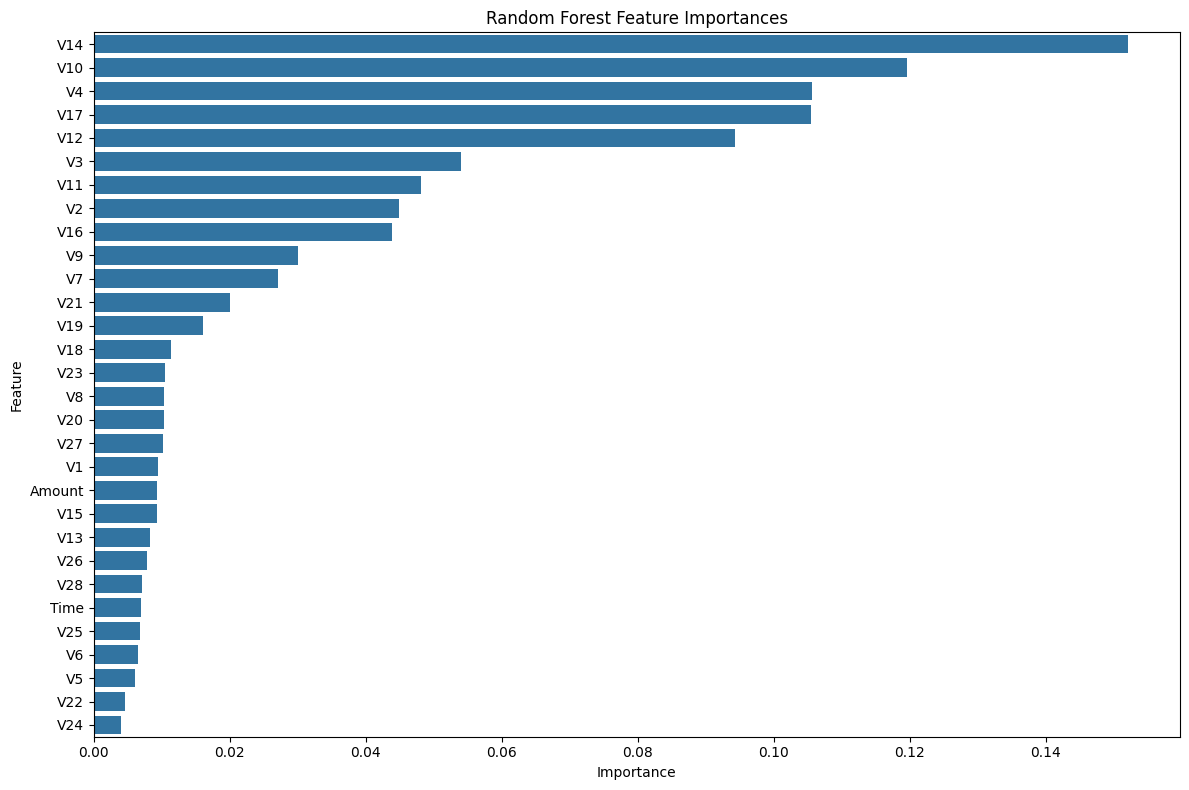

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = pd.Series(rand_forest_model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Logistic Regression on Original Dataset
print("--- Logistic Regression on Original Dataset ---")
y_pred_log_reg_original = log_reg_model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred_log_reg_original))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_log_reg_original))
print("Classification Report:\n", classification_report(y, y_pred_log_reg_original))

--- Logistic Regression on Original Dataset ---
Accuracy: 0.9746600329345838
Confusion Matrix:
 [[277153   7162]
 [    55    437]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99    284315
           1       0.06      0.89      0.11       492

    accuracy                           0.97    284807
   macro avg       0.53      0.93      0.55    284807
weighted avg       1.00      0.97      0.99    284807



In [ ]:
# Decision Tree Classifier on Original Dataset
print("\n--- Decision Tree Classifier on Original Dataset ---")
y_pred_dec_tree_original = dec_tree_model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred_dec_tree_original))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_dec_tree_original))
print("Classification Report:\n", classification_report(y, y_pred_dec_tree_original))


--- Decision Tree Classifier on Original Dataset ---
Accuracy: 0.9021021252988866
Confusion Matrix:
 [[256447  27868]
 [    14    478]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95    284315
           1       0.02      0.97      0.03       492

    accuracy                           0.90    284807
   macro avg       0.51      0.94      0.49    284807
weighted avg       1.00      0.90      0.95    284807



In [ ]:
# Random Forest Classifier on Original Dataset
print("\n--- Random Forest Classifier on Original Dataset ---")
y_pred_rand_forest_original = rand_forest_model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred_rand_forest_original))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_rand_forest_original))
print("Classification Report:\n", classification_report(y, y_pred_rand_forest_original))


--- Random Forest Classifier on Original Dataset ---
Accuracy: 0.9743861632614367
Confusion Matrix:
 [[277033   7282]
 [    13    479]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99    284315
           1       0.06      0.97      0.12       492

    accuracy                           0.97    284807
   macro avg       0.53      0.97      0.55    284807
weighted avg       1.00      0.97      0.99    284807

